# Overview

This optional activity helps us understand alternative clustering techniques (please complete the portfolio prior to attempting this activity)

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler


## The limits of KMeans

### Let's look at some complex shapes

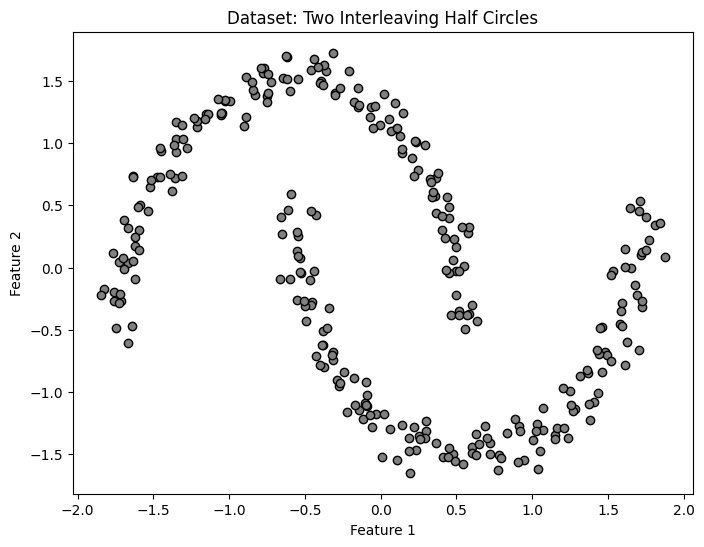

In [4]:

X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', edgecolor='k')
plt.title('Dataset: Two Interleaving Half Circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


### Questions: Suitability for KMeans

1. How many clusters do you see?
2. Is K-Means suitable? Why/why not?
3. Where would an optimal elbow be for this data set be in KMeans? Predict
4. How will it allocate shapes to clusters given k=2?

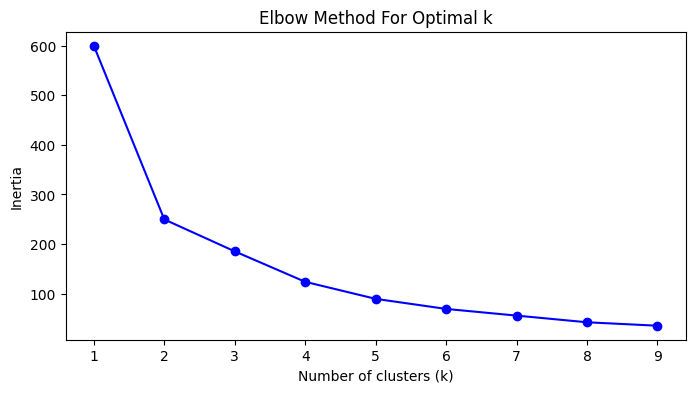

In [5]:
inertias = []
k_values = range(1, 10)
for k in k_values:
    kmeans = KMeans(k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_values)
plt.show()

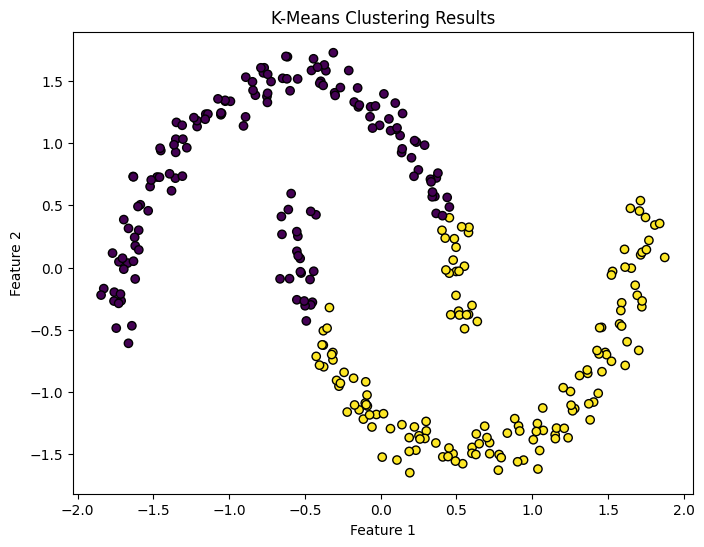

In [10]:

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
labels_kmeans = kmeans.labels_


plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap='viridis', edgecolor='k')
plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


### Reflect

1. Try the above with the "optimal" number of clusters
   > With it's optimal number of cluster 2 it still seems to group some cluster away from its centroid. I don't think it's accurate. 
2. Did it seem to do a better job classifying or interpreting the data?
   > It does a good enough job at classifying or interpreting the data, personally I wouldn't use k-means for this particular dataset. 
3. What does that tell us about KMeans? Is there some parameter we are likely to find that will work for this pattern?
   > That tells us that KMeans is only reliable if the data is 2 or 3 dimensional and is not sutaible for all data sets especially not a symetrical shaped one.  
4. Remember: IRL, pattern misfits can be harder to identify!

## DBSCAN

Run the code below, to see that it can partition the data. Don't worry too much about how it does it, just yet.

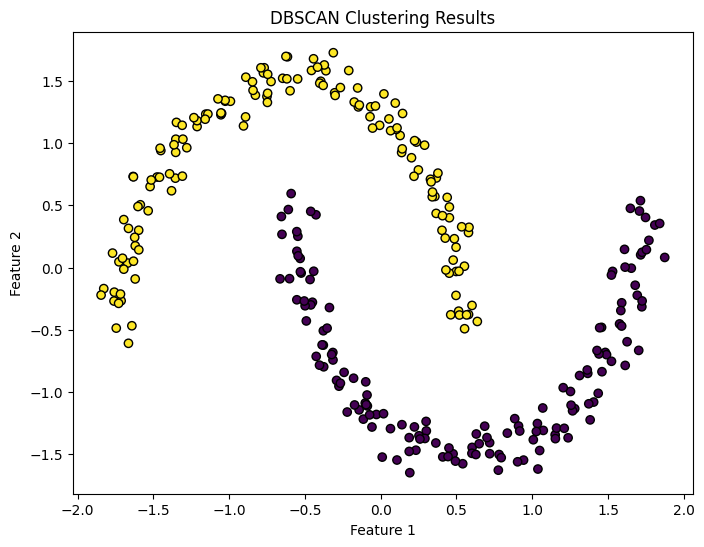

In [11]:

dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X_scaled)
labels_dbscan = dbscan.labels_


plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap='viridis', edgecolor='k')
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


> Note: Points labelled as -1 are considered noise by DBSCAN.

Corollary: could KMeans identify noise?
> Could KMeans identify noise...
> K-means clustering can be sensitive to noise in datasets, which may lead to inaccurate clustering results. While K-means is effective for identifying clusters, it can struggle with noise data points, which may distort the clustering process. To improve performance, techniques such as outlier detection, data normalization, and using K-means with noise-excluding methods can be employed to enhance the clustering results and reduce the impact of noise

> https://ieeexplore.ieee.org/document/1374211

### Understand DBSCAN parameters

#### Epsilon (`eps`) and `min_samples`

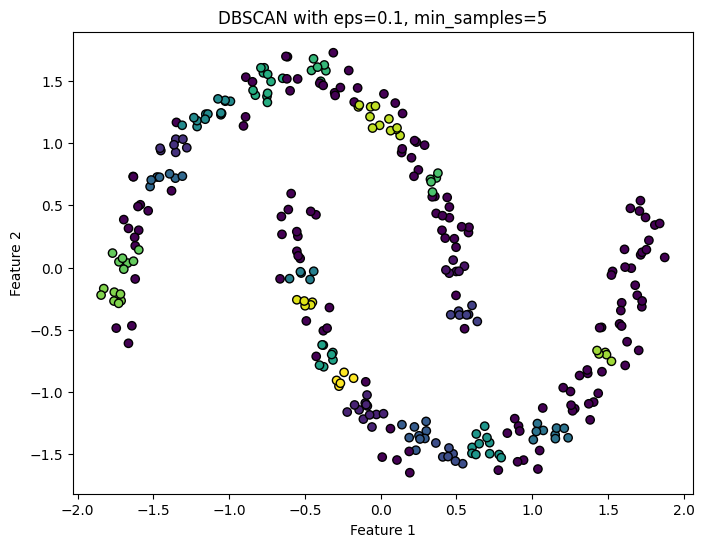

In [12]:
# Eps and min_samples -> 
dbscan_eps_small = DBSCAN(eps=0.1, min_samples=5)
dbscan_eps_small.fit(X_scaled)
labels_eps_small = dbscan_eps_small.labels_


plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_eps_small, cmap='viridis', edgecolor='k')
plt.title('DBSCAN with eps=0.1, min_samples=5')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


2


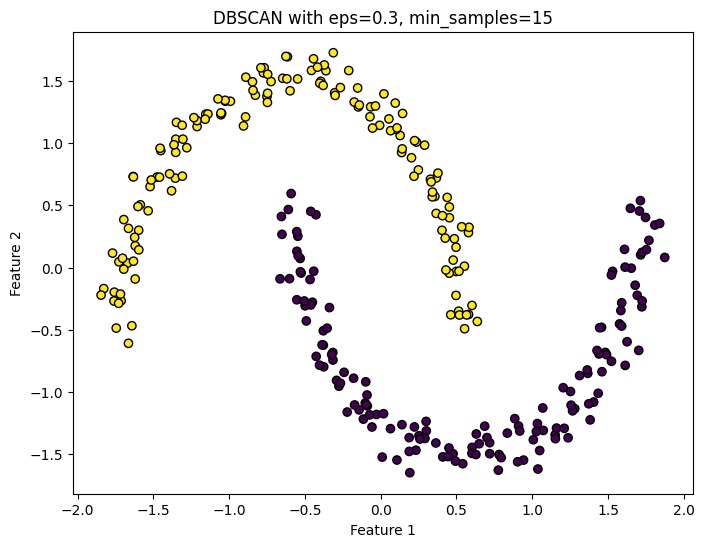

In [7]:
# Increase min_samples
dbscan_min_samples_large = DBSCAN(eps=0.3, min_samples=5)
dbscan_min_samples_large.fit(X_scaled)
labels_min_samples_large = dbscan_min_samples_large.labels_

# Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_min_samples_large, cmap='viridis', edgecolor='k')
plt.title('DBSCAN with eps=0.3, min_samples=15')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
print(len(np.unique(labels_min_samples_large)))
plt.show()


#### Challenge

Examine the results and try additional adjustments to epsilon and min_samples. Try and form an hypothesis as to how these parameters affect the model (don't worry, nothing to hand it - just put your best guess down!)

**`eps`**
> 0.2

**`min_samples`**
> 6

3


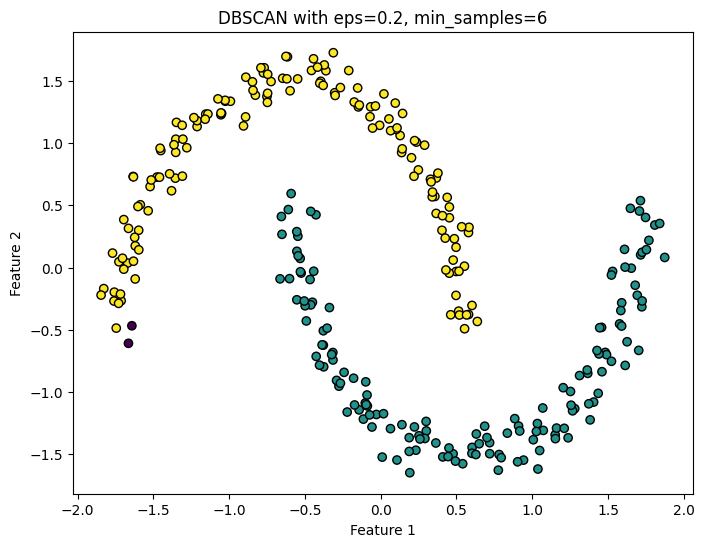

In [25]:
# Increase min_samples
dbscan_min_samples_large = DBSCAN(eps=0.2, min_samples=6)
dbscan_min_samples_large.fit(X_scaled)
labels_min_samples_large = dbscan_min_samples_large.labels_

# Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_min_samples_large, cmap='viridis', edgecolor='k')
plt.title('DBSCAN with eps=0.2, min_samples=6')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
print(len(np.unique(labels_min_samples_large)))
plt.show()


## Conclusion


- **K-Means Clustering**

  - **Assumptions**: Clusters are spherical and of similar size.
  - **Parameters**: Number of clusters (\( k \)).
  - **Advantages**: Simple and computationally efficient.
  - **Limitations**: Not effective with clusters of arbitrary shapes; sensitive to outliers.

- **DBSCAN Clustering**

  - **Concept**: Density-based clustering; groups together points that are close together
  - **Parameters**: `eps` (neighbourhood radius), `min_samples` (minimum number of points to form a cluster).
  - **Advantages**: Can find clusters of arbitrary shape; identifies noise/outliers.
  - **Limitations**: Parameter selection can be challenging; not suitable for datasets with varying densities.

### When to Use Which Algorithm

- **Use K-Means when**:

  - The data has a simple structure with well-separated, spherical clusters.
  - You know the number of clusters in advance.
  - Computational efficiency is important.

- **Use DBSCAN when**:

  - The data has clusters of arbitrary shapes.
  - You expect noise and outliers in the data.
  - The number of clusters is unknown.

---

## Additional Notes

### Parameter Selection in DBSCAN

- **`eps` (epsilon)**: Maximum distance between two samples for one to be considered as in the neighbourhood of the other.
- **`min_samples`**: The number of samples (or total weight) within epsilon to be considered a core point.

**Tip**: Use a k-distance graph to help determine a good value for `eps`.



## Optional Challenge

### Estimating `eps` Using the k-Distance Graph

Plot the sorted distances to the k-nearest neighbour for each point and look for a "knee" in the curve to estimate a good `eps` value.


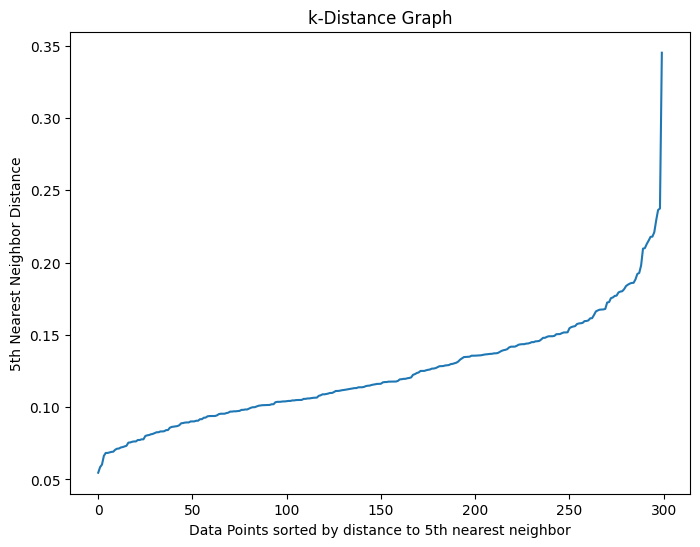

In [8]:

from sklearn.neighbors import NearestNeighbors

# Example data (replace with your dataset)
X = X_scaled


min_samples = 5

# Nearest 
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distances for the k-distance graph
distances = np.sort(distances[:, min_samples - 1], axis=0)

# Plot the k-distance graph
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.xlabel("Data Points sorted by distance to {}th nearest neighbor".format(min_samples))
plt.ylabel("{}th Nearest Neighbor Distance".format(min_samples))
plt.title("k-Distance Graph")
plt.show()


## Additional Reading and Exercises

See [Python Data Science Handbook](https://learning.oreilly.com/library/view/python-data-science/9781098121211/ch47.html#ch_0511-k-means_introducing-k-means)

[Clustering Examples](https://scikit-learn.org/stable/auto_examples/cluster/index.html)

[More on DBSCAN](https://www.datacamp.com/tutorial/dbscan-clustering-algorithm)